# Introduction

In this project, you will build a neural network of your own design to evaluate the CIFAR-10 dataset.
Our target accuracy is 70%, but any accuracy over 50% is a great start.
Some of the benchmark results on CIFAR-10 include:

78.9% Accuracy | [Deep Belief Networks; Krizhevsky, 2010](https://www.cs.toronto.edu/~kriz/conv-cifar10-aug2010.pdf)

90.6% Accuracy | [Maxout Networks; Goodfellow et al., 2013](https://arxiv.org/pdf/1302.4389.pdf)

96.0% Accuracy | [Wide Residual Networks; Zagoruyko et al., 2016](https://arxiv.org/pdf/1605.07146.pdf)

99.0% Accuracy | [GPipe; Huang et al., 2018](https://arxiv.org/pdf/1811.06965.pdf)

98.5% Accuracy | [Rethinking Recurrent Neural Networks and other Improvements for ImageClassification; Nguyen et al., 2020](https://arxiv.org/pdf/2007.15161.pdf)

Research with this dataset is ongoing. Notably, many of these networks are quite large and quite expensive to train. 

## Imports

In [4]:
## This cell contains the essential imports you will need – DO NOT CHANGE THE CONTENTS! ##
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np

## Load the Dataset

Specify your transforms as a list first.
The transforms module is already loaded as `transforms`.

CIFAR-10 is fortunately included in the torchvision module.
Then, you can create your dataset using the `CIFAR10` object from `torchvision.datasets` ([the documentation is available here](https://pytorch.org/docs/stable/torchvision/datasets.html#cifar)).
Make sure to specify `download=True`! 

Once your dataset is created, you'll also need to define a `DataLoader` from the `torch.utils.data` module for both the train and the test set.

In [198]:
# Define transforms
## YOUR CODE HERE ##
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])

transform_image_view = transforms.Compose([transforms.ToTensor()])

# Create training set and define training dataloader
## YOUR CODE HERE ##
trainset = datasets.CIFAR10('~/.pytorch/CIFAR10/', download=True, train=True, transform=train_transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# Create test set and define test dataloader
## YOUR CODE HERE ##
testset = datasets.CIFAR10('~/.pytorch/CIFAR10/', download=True, train=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)

# explore data
image_view = datasets.CIFAR10('~/.pytorch/CIFAR10/', download=True, train=True, transform=transform_image_view)
image_loader = torch.utils.data.DataLoader(image_view, batch_size=64, shuffle=True)
# The 10 classes in the dataset
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [49]:
dataiter = iter(trainloader)
images, labels = dataiter.__next__()
print(images.type())
print(images.shape)
print(labels.shape)

torch.FloatTensor
torch.Size([64, 3, 32, 32])
torch.Size([64])


## Explore the Dataset
Using matplotlib, numpy, and torch, explore the dimensions of your data.

You can view images using the `show5` function defined below – it takes a data loader as an argument.
Remember that normalized images will look really weird to you! You may want to try changing your transforms to view images.
Typically using no transforms other than `toTensor()` works well for viewing – but not as well for training your network.
If `show5` doesn't work, go back and check your code for creating your data loaders and your training/test sets.

In [11]:
def show5(img_loader):
    dataiter = iter(img_loader)
    
    batch = next(dataiter)
    labels = batch[1][0:5]
    images = batch[0][0:5]
    for i in range(5):
        print(classes[labels[i]])
    
        image = images[i].numpy()
        plt.imshow(image.T)
        plt.show()

ship


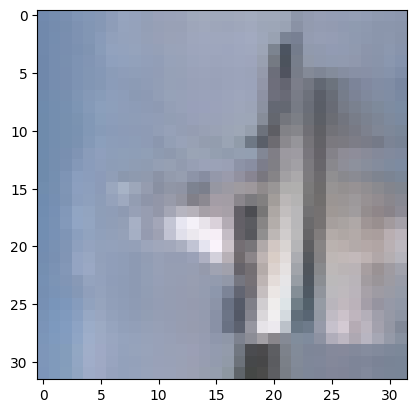

car


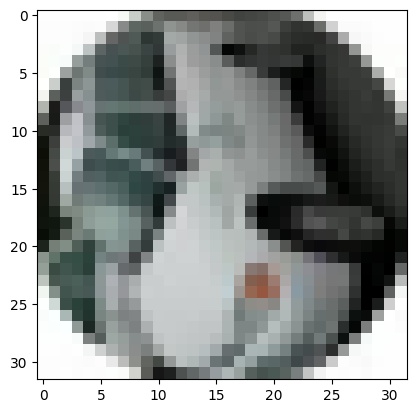

deer


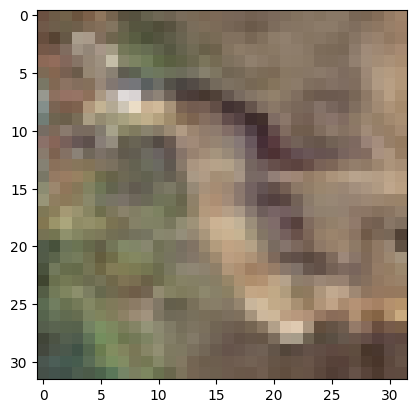

cat


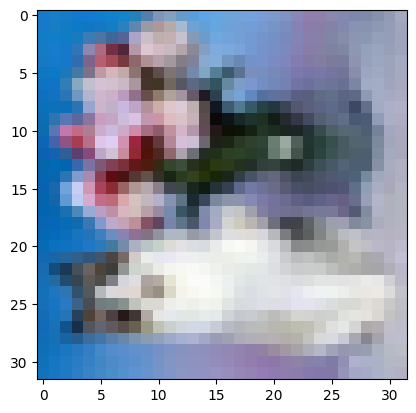

deer


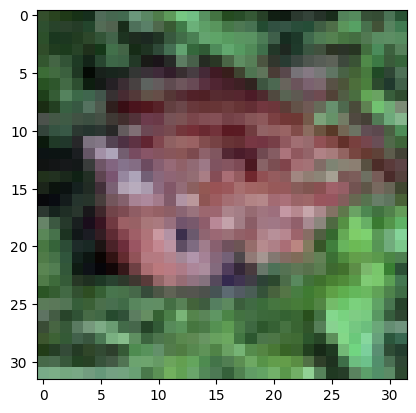

In [19]:
# Explore data
## YOUR CODE HERE ##

show5(image_loader)

## Build your Neural Network
Using the layers in `torch.nn` (which has been imported as `nn`) and the `torch.nn.functional` module (imported as `F`), construct a neural network based on the parameters of the dataset. 
Feel free to construct a model of any architecture – feedforward, convolutional, or even something more advanced!

In [199]:
## YOUR CODE HERE ##
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3072, 64)
        self.fc2 = nn.Linear(64, 10)
        
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        x = x.view(x.shape[0], -1) # falten the image
        
        x = self.dropout(F.relu(self.fc1(x)))
        x = F.log_softmax(self.fc2(x), dim = 1)
        return x

Specify a loss function and an optimizer, and instantiate the model.

If you use a less common loss function, please note why you chose that loss function in a comment.

In [202]:
## YOUR CODE HERE ##
model = Classifier()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.NLLLoss()
epochs = 50
steps = 0

In [203]:
device = torch.device(gpu if torch.cuda.is_available() else "cpu")
model.to(device)

Classifier(
  (fc1): Linear(in_features=3072, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

## Running your Neural Network
Use whatever method you like to train your neural network, and ensure you record the average loss at each epoch. 
Don't forget to use `torch.device()` and the `.to()` method for both your model and your data if you are using GPU!

If you want to print your loss during each epoch, you can use the `enumerate` function and print the loss after a set number of batches. 250 batches works well for most people!

In [204]:
## YOUR CODE HERE ##
from time import time
train_losses, test_losses = [], []
start_time = time()
for e in range(epochs):
    running_loss = 0
    for images, labels in trainloader:
        
        optimizer.zero_grad()
        
        log_ps = model(images)
        loss = criterion(log_ps, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    else:
        correct_prediction = 0
        incorrect_prediction = 0
        with torch.no_grad():
            model.eval()
            for images, labels in testloader:
                log_ps = model(images)
                
                incorrect_prediction += criterion(log_ps, labels)

                ps = torch.exp(log_ps)
                _, top_class = ps.topk(1, dim=1)
                equals = top_class == labels.view(*top_class.shape)
                correct_prediction += equals.sum().item()
                
        model.train()
        test_loss = incorrect_prediction / len(testloader)
        train_loss = running_loss / len(trainloader)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        
        print(f"Epoch {e + 1}/{epochs},\
        training_loss: {train_losses[-1]:.3f},\
        test_loss: {test_losses[-1]:.3f},\
        Accuracy: {correct_prediction / len(testloader.dataset)}")
end_time = time()
Time_elapsed = end_time - start_time
print("Time used: ", Time_elapsed)

Epoch 1/50,        training_loss: 1.908,        test_loss: 1.683,        Accuracy: 0.3998
Epoch 2/50,        training_loss: 1.789,        test_loss: 1.621,        Accuracy: 0.4266
Epoch 3/50,        training_loss: 1.739,        test_loss: 1.590,        Accuracy: 0.4398
Epoch 4/50,        training_loss: 1.714,        test_loss: 1.565,        Accuracy: 0.448
Epoch 5/50,        training_loss: 1.695,        test_loss: 1.554,        Accuracy: 0.445
Epoch 6/50,        training_loss: 1.685,        test_loss: 1.543,        Accuracy: 0.4523
Epoch 7/50,        training_loss: 1.674,        test_loss: 1.542,        Accuracy: 0.4535
Epoch 8/50,        training_loss: 1.667,        test_loss: 1.518,        Accuracy: 0.4651
Epoch 9/50,        training_loss: 1.659,        test_loss: 1.519,        Accuracy: 0.4679
Epoch 10/50,        training_loss: 1.652,        test_loss: 1.507,        Accuracy: 0.4673
Epoch 11/50,        training_loss: 1.639,        test_loss: 1.512,        Accuracy: 0.4721
Epoch 12/5

Plot the training loss (and validation loss/accuracy, if recorded).

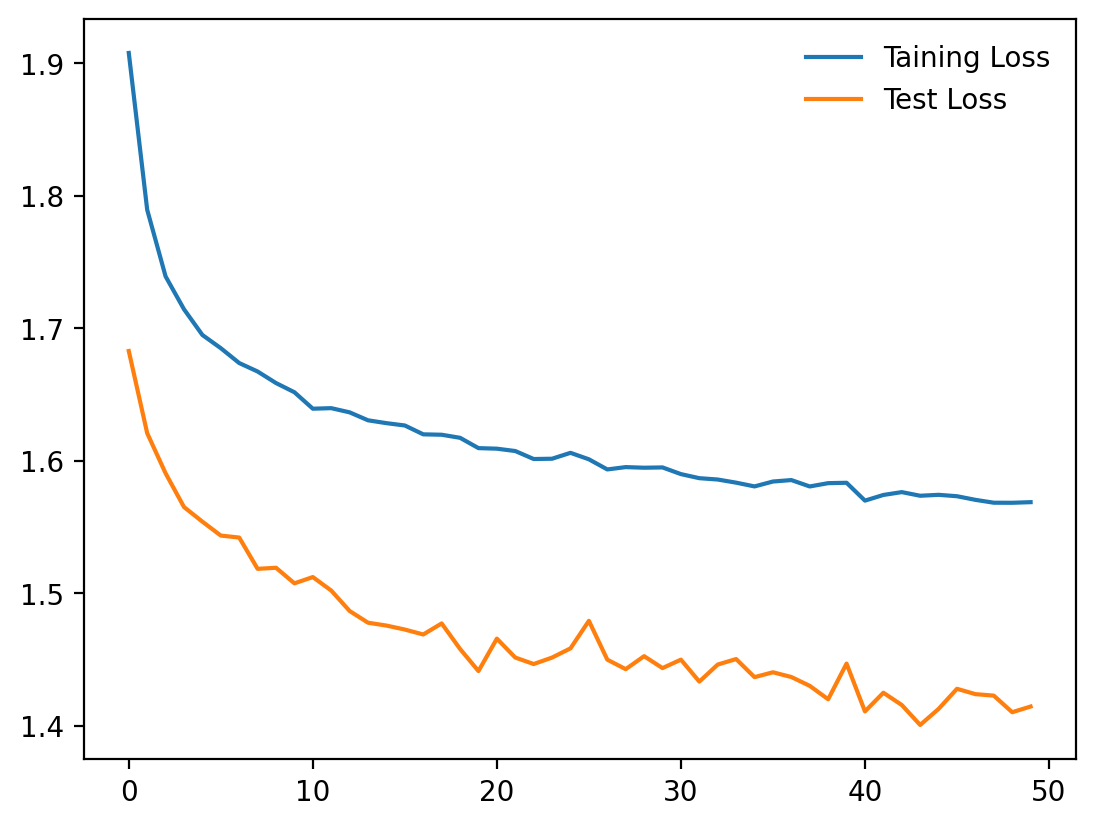

In [205]:
## YOUR CODE HERE ##
import matplotlib.pyplot as plt
%matplotlib inline 
%config InlineBackend.figure_format = 'retina'

plt.plot(train_losses, label="Taining Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend(frameon=False)
plt.show()

>**Continuous training with more Iterations will lead to a better model with higher accuracy**

## Testing your model
Using the previously created `DataLoader` for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is over 70%, great work! 
This is a hard task to exceed 70% on.

If your accuracy is under 45%, you'll need to make improvements.
Go back and check your model architecture, loss function, and optimizer to make sure they're appropriate for an image classification task.

In [210]:
## YOUR CODE HERE ##
test_range = 5
for e in range(test_range):
    correct_prediction = 0
    incorrect_prediction = 0
    with torch.no_grad():
        model.eval()
        for images, labels in testloader:
            log_ps = model(images)

            incorrect_prediction += criterion(log_ps, labels)

            ps = torch.exp(log_ps)
            _, top_class = ps.topk(1, dim=1)
            equals = top_class == labels.view(*top_class.shape)
            correct_prediction += equals.sum().item()
            
    test_loss = incorrect_prediction / len(testloader)
    test_losses.append(test_loss)
    print(f"Epoch {e + 1}/{test_range}, \
    test_loss: {test_losses[-1]:.3f}, \
    Accuracy: {(correct_prediction / len(testloader.dataset)) * 100 :.2f}%")

Epoch 1/5,     test_loss: 1.418,     Accuracy: 50.26%
Epoch 2/5,     test_loss: 1.417,     Accuracy: 50.26%
Epoch 3/5,     test_loss: 1.419,     Accuracy: 50.26%
Epoch 4/5,     test_loss: 1.417,     Accuracy: 50.26%
Epoch 5/5,     test_loss: 1.417,     Accuracy: 50.26%


## Saving your model
Using `torch.save`, save your model for future loading.

In [211]:
print("Model State Dict: ")
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor].size())

Model State Dict: 
fc1.weight 	 torch.Size([64, 3072])
fc1.bias 	 torch.Size([64])
fc2.weight 	 torch.Size([10, 64])
fc2.bias 	 torch.Size([10])


In [212]:
print("Optimizer's State Dict: ")
for var_name in optimizer.state_dict():
    print(var_name, "\t", optimizer.state_dict()[var_name])

Optimizer's State Dict: 
state 	 {0: {'step': tensor(39100.), 'exp_avg': tensor([[ 4.7265e-04,  5.9454e-04,  6.4688e-04,  ...,  3.6268e-04,
          9.5035e-05,  5.1232e-05],
        [ 1.4295e-03,  1.1484e-03,  1.1491e-03,  ...,  1.8689e-03,
          1.8954e-03,  1.6372e-03],
        [-1.0694e-05,  2.3313e-05, -2.8421e-04,  ...,  1.6722e-04,
          4.2785e-05,  7.5523e-05],
        ...,
        [-7.2293e-04, -6.0840e-04, -4.1065e-04,  ..., -1.5877e-04,
         -3.8971e-06,  4.5394e-05],
        [-1.5664e-04, -1.6272e-04,  7.5441e-05,  ..., -6.9555e-04,
         -7.4164e-04, -6.6334e-04],
        [ 4.0985e-04,  3.0459e-04,  2.4799e-04,  ..., -1.7722e-04,
         -1.6098e-04,  1.8239e-04]]), 'exp_avg_sq': tensor([[5.0395e-06, 4.8702e-06, 4.6987e-06,  ..., 4.5145e-06, 4.8076e-06,
         5.0317e-06],
        [7.3935e-06, 6.3843e-06, 5.5909e-06,  ..., 1.1169e-05, 1.1254e-05,
         1.1320e-05],
        [3.2150e-06, 2.8849e-06, 2.5945e-06,  ..., 3.4628e-06, 3.5496e-06,
         3.

In [213]:
## YOUR CODE HERE ##
import os
save_dir = "."
save_path = os.path.join(save_dir, 'checkpoint.pth')
torch.save({
            'epoch': epochs,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': train_losses,
            }, save_path)

## Make a Recommendation

Based on your evaluation, what is your recommendation on whether to build or buy? Explain your reasoning below.



**My recommendation would be to build. The above model has an accuracy of 50.26% and can still be improved with additional training. Furthermore, training is not much of compute intensive and it is just a one time event. The inhouse model has some merit over the purchased model**
1. Privacy: There is control over the model, and no black-boxing
2. Ethics: The model is transparent to us as we know "The How", "The what" and "The why" and can add rules without limitation.
3. Monitoring: We can monitor and observe the behaviour of the model.
4. Cost savings in the long run will be a thousand times cheaper than the purchased model
5. No worries of adding more devices during inference for fear of more tokens increasing the monthly subscription bills.

